# Public Wi-Fi Access Across New York City

**Author:** Jennifer Zhang  
**Mapping Systems — Assignment 01: Loading and Visualizing Data**

**Research question:** How does the published inventory of public Wi-Fi differ across New York City's five boroughs, both in the concentration of recorded hotspots and in their listed access type?

This notebook uses NYC Open Data's [NYC Wi-Fi Hotspot Locations](https://data.cityofnewyork.us/d/yjub-udmw) dataset and the Department of City Planning's [Borough Boundaries](https://data.cityofnewyork.us/d/gthc-hcne). Both snapshots were downloaded on 2026-08-07.

The unit of analysis is a **published hotspot record**. A row is not a user, a household, a measured coverage area, or proof that a connection currently works.

In [1]:
from pathlib import Path
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=UserWarning)
DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (11, 7),
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "font.size": 10,
})

## 1. Why these attributes?

I focus on exactly two published attributes:

| Attribute | Meaning in this dataset | Why I chose it |
|---|---|---|
| `boroname` | Borough assigned to each hotspot record | It enables a recognizable citywide comparison and can be joined to official borough geometry. |
| `type` | Published access category: `Free`, `Limited Free`, or `Partner Site` | A hotspot count alone does not describe what kind of access is being offered. |

Latitude and longitude are used to draw points, but they are location fields rather than the substantive comparison. Borough area is used to derive **records per square mile**, so that a physically large borough is not automatically treated as having better provision.

I considered `provider`, but did not make it a primary attribute. Provider names describe operators, while this assignment is asking a more focused question about the geography and published form of access.

## 2. Load and audit the data

Before visualizing, I inspect row count, columns, missing values, identifiers, coordinates, and geometry. This matters because a polished map can still be misleading if the unit of analysis or data quality is unclear.

In [2]:
raw = pd.read_csv(DATA_DIR / "nyc_wifi_hotspots.csv")
boroughs = gpd.read_file(DATA_DIR / "nyc_borough_boundaries.geojson")

print(f"Wi-Fi records: {len(raw):,}")
print(f"Wi-Fi attributes: {len(raw.columns)}")
print(f"Borough polygons: {len(boroughs)}")
print(f"Boundary CRS: {boroughs.crs}")
print("\nWi-Fi columns:")
print(", ".join(raw.columns))

raw[["objectid", "name", "boroname", "type", "provider", "latitude", "longitude"]].head()

Wi-Fi records: 3,319
Wi-Fi attributes: 29
Borough polygons: 5
Boundary CRS: EPSG:4326

Wi-Fi columns:
objectid, borough, type, provider, name, location, latitude, longitude, x, y, location_t, remarks, city, ssid, sourceid, activated, borocode, boroname, ntacode, ntaname, coundist, zip, borocd, ct2010, bctcb2010, bin, bbl, doitt_id, location_lat_long


,objectid,name,boroname,type,provider,latitude,longitude
0,10604,Baisley Pond Park,Queens,Limited Free,SPECTRUM,40.674860,-73.784120
1,10555,Kissena Park,Queens,Limited Free,SPECTRUM,40.747560,-73.818150
2,12370,Grand St (L),Brooklyn,Free,Transit Wireless,40.711926,-73.940670
3,9893,NaN,Brooklyn,Free,Downtown Brooklyn,40.689985,-73.991995
4,10169,Lexington Av-63 St (F),Manhattan,Free,Transit Wireless,40.764630,-73.966115


In [3]:
audit_fields = ["objectid", "boroname", "type", "latitude", "longitude"]
audit = pd.DataFrame({
    "dtype": raw[audit_fields].dtypes.astype(str),
    "missing": raw[audit_fields].isna().sum(),
    "unique_values": raw[audit_fields].nunique(dropna=True),
})
display(audit)

clean = raw.dropna(subset=["objectid", "boroname", "type", "latitude", "longitude"]).copy()
clean = clean[
    clean["longitude"].between(-74.30, -73.65)
    & clean["latitude"].between(40.45, 40.95)
].copy()

hotspots = gpd.GeoDataFrame(
    clean,
    geometry=gpd.points_from_xy(clean["longitude"], clean["latitude"]),
    crs="EPSG:4326",
)

print(f"Usable spatial records: {len(hotspots):,} ({len(hotspots) / len(raw):.1%})")
print(f"Duplicated object IDs: {hotspots['objectid'].duplicated().sum():,}")
print(f"Rows sharing a latitude/longitude pair: {hotspots.duplicated(['latitude', 'longitude']).sum():,}")

,dtype,missing,unique_values
objectid,int64,0,3319
boroname,str,0,5
type,str,0,3
latitude,float64,0,3149
longitude,float64,0,3149


Usable spatial records: 3,319 (100.0%)
Duplicated object IDs: 0
Rows sharing a latitude/longitude pair: 169


All 3,319 rows have the selected attributes and valid NYC-range coordinates, and `objectid` is unique. However, 169 rows share a coordinate pair with another record. These may represent colocated services or multiple inventory entries, so the analysis consistently says **records**, not unique devices.

The point coordinates are also checked against the official borough polygons below. A coastline point may fall just outside the clipped land boundary; this is a geometry-alignment issue, not enough evidence to delete the record.

In [4]:
boroughs_2263 = boroughs.to_crs("EPSG:2263").copy()
hotspots_2263 = hotspots.to_crs("EPSG:2263")

spatial_check = gpd.sjoin(
    hotspots_2263[["objectid", "boroname", "geometry"]],
    boroughs_2263[["boroname", "geometry"]],
    how="left",
    predicate="within",
    lsuffix="listed",
    rsuffix="boundary",
)

inside = spatial_check["boroname_boundary"].notna().sum()
matching = (spatial_check["boroname_listed"] == spatial_check["boroname_boundary"]).sum()
print(f"Points inside a clipped borough polygon: {inside:,} of {len(hotspots):,}")
print(f"Listed borough matches spatial borough: {matching:,} of {len(hotspots):,}")

Points inside a clipped borough polygon: 3,318 of 3,319
Listed borough matches spatial borough: 3,318 of 3,319


## 3. Construct two interpretable measures

The raw record count answers: **How many rows are listed for each borough?** It does not make boroughs comparable in size.

I therefore calculate:

1. **Recorded hotspots per square mile** = hotspot records ÷ clipped borough land area.
2. **Listed free share** = records labeled `Free` ÷ all hotspot records in that borough.

The first is an area-normalized inventory density, not population access. The second describes the published label, not speed, uptime, or the absence of login conditions.

In [5]:
boroughs_2263["area_sq_mi"] = boroughs_2263.geometry.area / (5280 ** 2)

type_counts = pd.crosstab(hotspots["boroname"], hotspots["type"])
for category in ["Free", "Limited Free", "Partner Site"]:
    if category not in type_counts.columns:
        type_counts[category] = 0

borough_summary = boroughs_2263[["borocode", "boroname", "area_sq_mi", "geometry"]].merge(
    type_counts.reset_index(), on="boroname", how="left"
)
borough_summary["hotspot_records"] = borough_summary[["Free", "Limited Free", "Partner Site"]].sum(axis=1)
borough_summary["records_per_sq_mi"] = borough_summary["hotspot_records"] / borough_summary["area_sq_mi"]
borough_summary["free_share_pct"] = 100 * borough_summary["Free"] / borough_summary["hotspot_records"]

summary_table = borough_summary[
    ["boroname", "area_sq_mi", "hotspot_records", "records_per_sq_mi", "free_share_pct"]
].sort_values("records_per_sq_mi", ascending=False)

display(summary_table.style.format({
    "area_sq_mi": "{:.1f}",
    "hotspot_records": "{:,.0f}",
    "records_per_sq_mi": "{:.1f}",
    "free_share_pct": "{:.1f}%",
}))

overall_type = hotspots["type"].value_counts().rename_axis("access_type").to_frame("records")
overall_type["share_pct"] = 100 * overall_type["records"] / len(hotspots)
display(overall_type.style.format({"records": "{:,.0f}", "share_pct": "{:.1f}%"}))

,boroname,area_sq_mi,hotspot_records,records_per_sq_mi,free_share_pct
3,Manhattan,22.8,"1,672",73.2,94.1%
1,Brooklyn,69.4,700,10.1,77.1%
4,Bronx,42.6,316,7.4,62.0%
2,Queens,109.1,531,4.9,71.4%
0,Staten Island,58.2,100,1.7,48.0%


,records,share_pct
access_type,,
Free,"2,736",82.4%
Limited Free,581,17.5%
Partner Site,2,0.1%


## 4. Map 1 — area-normalized inventory density

### Why this map?

A choropleth is appropriate because the derived value belongs to borough areas, not to individual points. Mapping records per square mile tests whether raw totals are partly a consequence of borough size. The map uses only five polygons, so each value is labeled directly rather than hidden behind color alone.

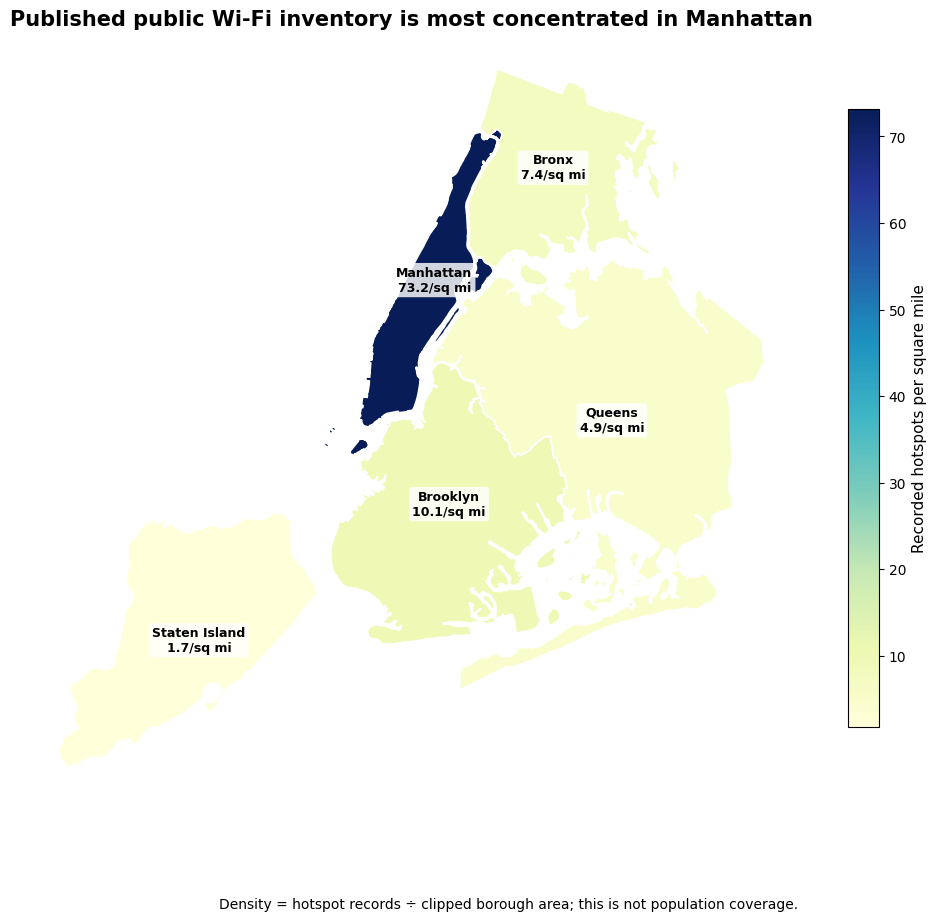

In [6]:
fig, ax = plt.subplots(figsize=(10, 10))
borough_summary.plot(
    ax=ax,
    column="records_per_sq_mi",
    cmap="YlGnBu",
    edgecolor="white",
    linewidth=1.2,
    legend=True,
    legend_kwds={"label": "Recorded hotspots per square mile", "shrink": 0.68},
)

for _, row in borough_summary.iterrows():
    p = row.geometry.representative_point()
    ax.annotate(
        f"{row.boroname}\n{row.records_per_sq_mi:.1f}/sq mi",
        (p.x, p.y),
        ha="center",
        va="center",
        fontsize=9,
        weight="bold",
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.82, "edgecolor": "none"},
    )

ax.set_title("Published public Wi-Fi inventory is most concentrated in Manhattan")
ax.set_axis_off()
fig.text(0.5, 0.04, "Density = hotspot records ÷ clipped borough area; this is not population coverage.", ha="center", fontsize=10)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(OUTPUT_DIR / "01_hotspot_density_choropleth.png", dpi=180, bbox_inches="tight")
plt.show()

Manhattan has **1,672 records** and **73.2 records per square mile**. Staten Island has **100 records** and **1.7 per square mile**. The density ratio is about 43:1.

This is a strong difference in the published inventory, but it cannot establish that a Manhattan resident is 43 times better connected. Borough population, daily visitors, public-space distribution, indoor access, and signal range are absent from the denominator.

## 5. Map 2 — point locations and listed access type

### Why a second map?

The choropleth summarizes borough averages and hides within-borough clustering. A point map restores the individual record locations. Color represents `type`, while the official borough polygons provide geographic context.

Overlapping points indicate many records at or near a location, but they do **not** depict Wi-Fi signal coverage.

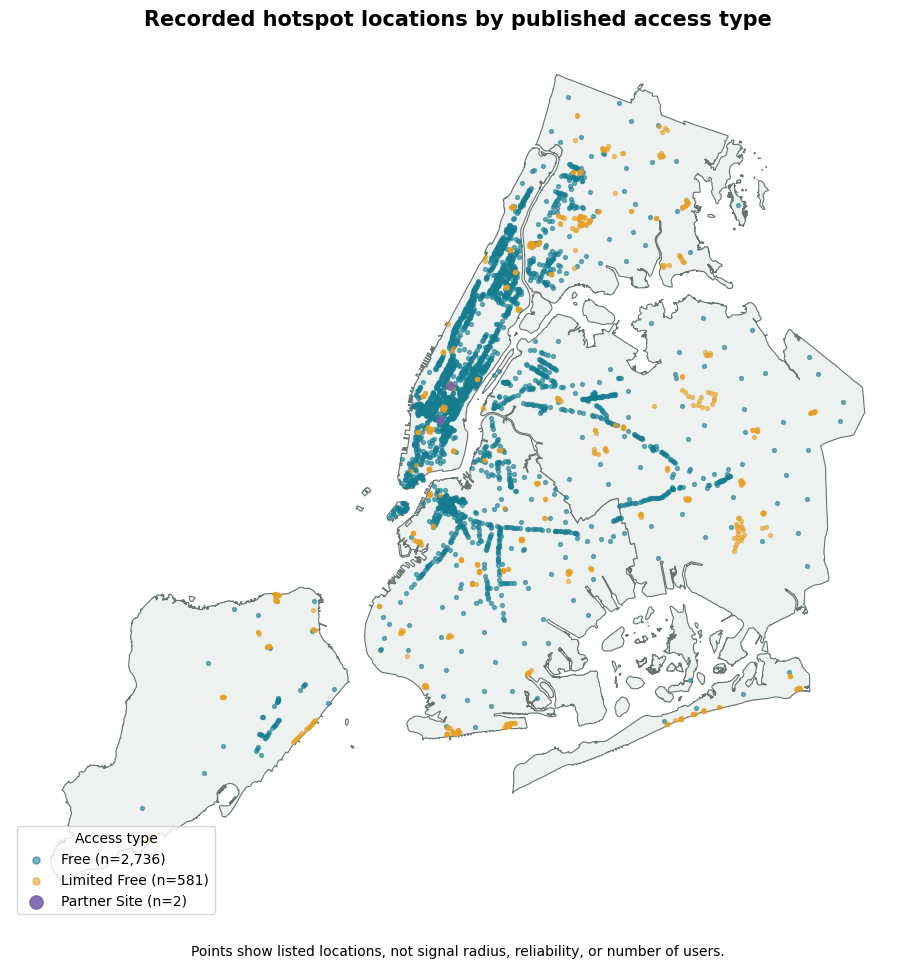

In [7]:
type_colors = {"Free": "#167d91", "Limited Free": "#e59f23", "Partner Site": "#7b61a8"}

fig, ax = plt.subplots(figsize=(10, 10))
boroughs_2263.plot(ax=ax, color="#edf1f0", edgecolor="#66736f", linewidth=0.8)

for access_type in ["Free", "Limited Free", "Partner Site"]:
    group = hotspots_2263[hotspots_2263["type"] == access_type]
    group.plot(
        ax=ax,
        color=type_colors[access_type],
        markersize=8 if access_type != "Partner Site" else 28,
        alpha=0.58 if access_type != "Partner Site" else 0.9,
        label=f"{access_type} (n={len(group):,})",
    )

ax.set_title("Recorded hotspot locations by published access type")
ax.set_axis_off()
ax.legend(title="Access type", loc="lower left", frameon=True, markerscale=1.8)
fig.text(0.5, 0.04, "Points show listed locations, not signal radius, reliability, or number of users.", ha="center", fontsize=10)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(OUTPUT_DIR / "02_hotspot_points_by_access_type.png", dpi=180, bbox_inches="tight")
plt.show()

The point map shows dense linear and clustered patterns, especially in Manhattan, rather than an even blanket of access. Across the full dataset, **2,736 of 3,319 records (82.4%)** are labeled `Free`, **581 (17.5%)** are `Limited Free`, and only **2 (0.1%)** are `Partner Site`.

These categories are administrative labels. They do not measure whether a connection was available during the download date or whether a user encountered a portal, time limit, device requirement, or weak signal.

## 6. Non-map visualization 1 — raw counts versus normalized density

### Why this chart?

Maps are good at showing spatial arrangement but make exact rank and magnitude comparisons difficult. Two aligned bar charts make the effect of the denominator explicit: the left panel shows the inventory count, and the right panel divides the same records by borough area.

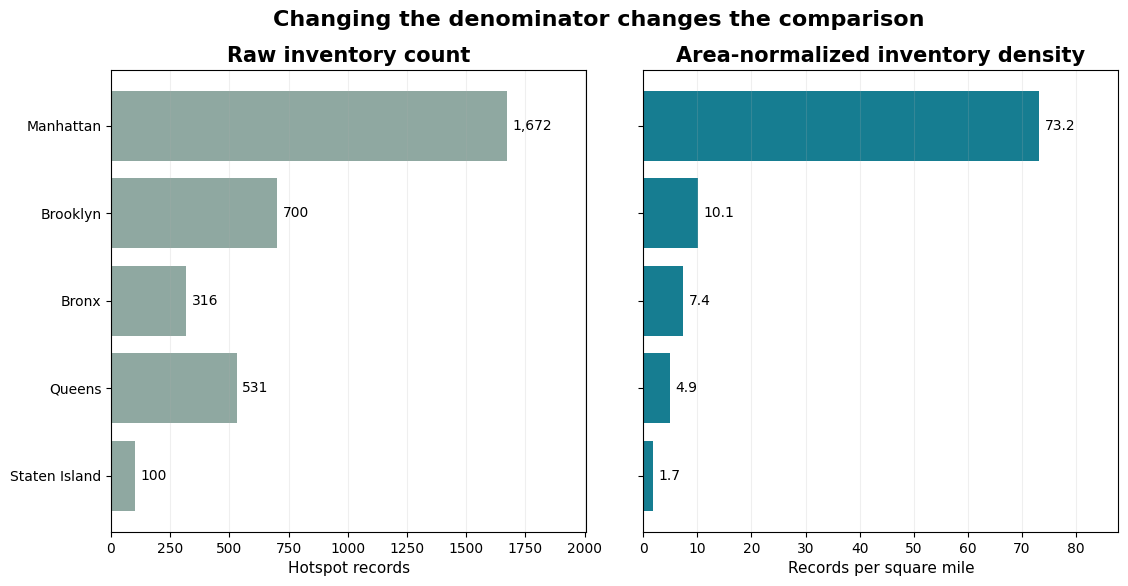

In [8]:
plot_order = summary_table.sort_values("records_per_sq_mi", ascending=True)
y = np.arange(len(plot_order))

fig, (ax_count, ax_density) = plt.subplots(1, 2, figsize=(13, 6), sharey=True, gridspec_kw={"wspace": 0.12})

ax_count.barh(y, plot_order["hotspot_records"], color="#8fa8a1")
ax_count.set_yticks(y, plot_order["boroname"])
ax_count.set_xlabel("Hotspot records")
ax_count.set_title("Raw inventory count")
ax_count.grid(axis="x", alpha=0.2)
for yi, value in zip(y, plot_order["hotspot_records"]):
    ax_count.text(value + 24, yi, f"{value:,.0f}", va="center")
ax_count.set_xlim(0, plot_order["hotspot_records"].max() * 1.20)

ax_density.barh(y, plot_order["records_per_sq_mi"], color="#167d91")
ax_density.set_xlabel("Records per square mile")
ax_density.set_title("Area-normalized inventory density")
ax_density.grid(axis="x", alpha=0.2)
for yi, value in zip(y, plot_order["records_per_sq_mi"]):
    ax_density.text(value + 1.1, yi, f"{value:.1f}", va="center")
ax_density.set_xlim(0, plot_order["records_per_sq_mi"].max() * 1.20)

fig.suptitle("Changing the denominator changes the comparison", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(OUTPUT_DIR / "03_count_vs_density.png", dpi=180, bbox_inches="tight")
plt.show()

Queens has more records than the Bronx (**531 versus 316**) but a lower area-normalized density (**4.9 versus 7.4 per square mile**) because Queens covers much more land. This is precisely what the raw count could not tell us.

Area normalization is not automatically “more correct.” It answers a different question and can still mislead if residents are concentrated in only part of a borough or frequently use Wi-Fi across borough boundaries.

## 7. Non-map visualization 2 — access-type composition

### Why a 100% stacked chart?

The citywide total is dominated by Manhattan. Converting each borough to 100% allows the composition of its published access types to be compared independently of the number of records. This chart answers a proportional question, not a question about total supply.

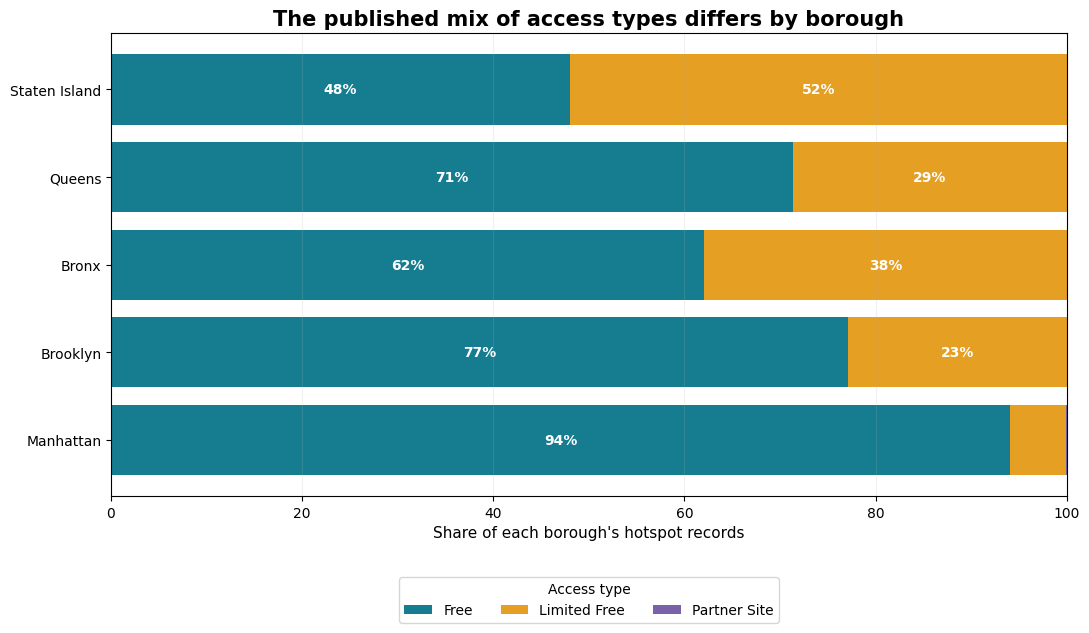

In [9]:
composition = type_counts[["Free", "Limited Free", "Partner Site"]].copy()
composition = composition.div(composition.sum(axis=1), axis=0) * 100
composition = composition.loc[summary_table["boroname"]]

fig, ax = plt.subplots(figsize=(11, 6.5))
left = np.zeros(len(composition))

for category in ["Free", "Limited Free", "Partner Site"]:
    values = composition[category].to_numpy()
    ax.barh(composition.index, values, left=left, color=type_colors[category], label=category)
    for yi, (start, value) in enumerate(zip(left, values)):
        if value >= 7:
            ax.text(start + value / 2, yi, f"{value:.0f}%", ha="center", va="center", color="white", fontweight="bold")
    left += values

ax.set_xlim(0, 100)
ax.set_xlabel("Share of each borough's hotspot records")
ax.set_ylabel("")
ax.set_title("The published mix of access types differs by borough")
ax.grid(axis="x", alpha=0.18)
ax.legend(title="Access type", bbox_to_anchor=(0.5, -0.16), loc="upper center", ncol=3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_access_type_composition.png", dpi=180, bbox_inches="tight")
plt.show()

The share labeled `Free` ranges from **94.1% in Manhattan** to **48.0% on Staten Island**. This reveals a compositional difference that the citywide 82.4% figure hides.

The chart does not show the absolute number of free records: a borough can have a high percentage but few total hotspots. It must therefore be read together with the count/density chart and maps.

## 8. What these attributes can and cannot tell us

### What the analysis can support

- Compare the number and area-normalized density of published hotspot records across boroughs.
- Compare the published mix of `Free`, `Limited Free`, and `Partner Site` records.
- Identify spatial clusters, borough-level contrasts, and locations that deserve closer investigation.
- Demonstrate how a denominator changes the interpretation of a raw count.

### What it cannot support on its own

- **Coverage:** a point is not a Wi-Fi signal radius or a walkshed.
- **Performance:** there are no measurements of speed, latency, uptime, congestion, or maintenance.
- **Use:** there are no users, sessions, devices, or demand estimates.
- **Population equity:** records per square mile are not records per resident, household, or person without home broadband.
- **Current availability:** the download is a snapshot of a published inventory, not a field audit.
- **Causal claims:** the maps cannot explain why boroughs differ.

The safe conclusion is that the **recorded public Wi-Fi inventory is spatially uneven and differently classified across boroughs**. It is not yet evidence of how many New Yorkers have reliable internet access.

In [10]:
summary_export = borough_summary.to_crs("EPSG:4326")[
    ["borocode", "boroname", "area_sq_mi", "hotspot_records", "records_per_sq_mi", "free_share_pct", "geometry"]
]
summary_export.to_file(OUTPUT_DIR / "borough_wifi_summary.geojson", driver="GeoJSON")
summary_export.drop(columns="geometry").to_csv(OUTPUT_DIR / "borough_wifi_summary.csv", index=False)

hotspots[["objectid", "name", "boroname", "type", "provider", "location_t", "geometry"]].to_file(
    OUTPUT_DIR / "nyc_wifi_hotspots_clean.geojson", driver="GeoJSON"
)

expected_figures = [
    "01_hotspot_density_choropleth.png",
    "02_hotspot_points_by_access_type.png",
    "03_count_vs_density.png",
    "04_access_type_composition.png",
]
for filename in expected_figures:
    path = OUTPUT_DIR / filename
    assert path.exists() and path.stat().st_size > 0, f"Missing output: {filename}"

print("Saved four figures, borough summary CSV/GeoJSON, and cleaned hotspot GeoJSON to outputs/.")

Saved four figures, borough summary CSV/GeoJSON, and cleaned hotspot GeoJSON to outputs/.


## 9. Next step

A stronger digital-equity analysis would join these records to population, household broadband subscription, public-library hours, and realistic walking catchments. A field audit of a sample of hotspots would be necessary before making claims about reliability or actual accessibility.